<a href="https://colab.research.google.com/github/lama-byte/ML_for_cybersecurity/blob/main/Baseline%20Reproduction/Reproduce_Baseline_PDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)

In [ ]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# read datasets
pdf_df = pd.read_csv("/content/PDF_Top10_features.csv")


### PDF Documents

In [ ]:
pdf_df.describe()

,text_length,total_filters,title_chars,file_size,object_count,stream_count,endstream_count,metadata_size,valid_pdf_header,entropy_of_streams,label
count,1.929600e+04,19296.000000,19296.000000,1.929600e+04,19296.000000,19296.000000,19296.000000,19296.000000,19296.000000,19296.000000,19296.000000
mean,8.761265e+03,12.871424,14.792548,7.130837e+04,270.254042,33.240309,16.619040,150.339138,0.611578,3.597990,0.518190
std,3.792156e+04,41.390530,19.411976,4.186992e+05,5074.942888,116.071443,58.032505,149.862796,0.487404,2.942377,0.499682
min,0.000000e+00,0.000000,0.000000,2.400000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000e+00,0.000000,0.000000,9.620000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.195000e+03,3.000000,8.000000,1.746200e+04,20.000000,6.000000,3.000000,137.000000,1.000000,5.317352,1.000000
75%,6.292500e+03,14.000000,25.000000,7.787650e+04,70.000000,32.000000,16.000000,251.000000,1.000000,6.131907,1.000000
max,3.415343e+06,3967.000000,289.000000,3.677767e+07,200006.000000,7952.000000,3976.000000,2560.000000,1.000000,7.177038,1.000000


In [ ]:
pdf_df.shape

(19296, 11)

In [ ]:
print(list(pdf_df.columns))

['text_length', 'total_filters', 'title_chars', 'file_size', 'object_count', 'stream_count', 'endstream_count', 'metadata_size', 'valid_pdf_header', 'entropy_of_streams', 'label']


In [ ]:
pdf_df.head()

,text_length,total_filters,title_chars,file_size,object_count,stream_count,endstream_count,metadata_size,valid_pdf_header,entropy_of_streams,label
0,8018,8,8,20362,120,18,9,254,1,6.010192,0
1,11568,7,35,28848,36,16,8,242,1,6.240051,0
2,1377,2,12,76563,21,4,2,138,1,5.830408,0
3,30607,11,8,67982,46,26,13,278,1,6.317049,0
4,1,2,37,3997,10,6,3,156,1,5.442597,1


In [ ]:
# valid_pdf_header is a binary flag as the paper says
pdf_df['valid_pdf_header'].unique()

array([1, 0])

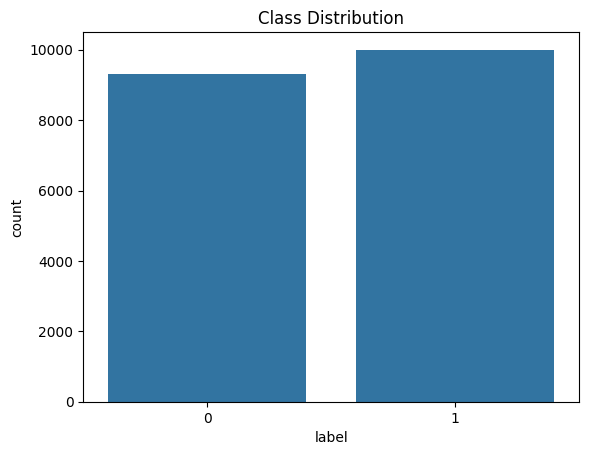

In [ ]:
# verify that the dataset is balanced (50% bengin, 50% malicious)

sns.countplot(data=pdf_df, x="label")
plt.title("Class Distribution")
plt.show()

In [ ]:
# there is some lost samples here!!
benign_count = (pdf_df["label"] == 0).sum()
malicious_count = (pdf_df["label"] == 1).sum()

print("Benign:", benign_count)
print("Malicious:", malicious_count)

Benign: 9297
Malicious: 9999


<Axes: >

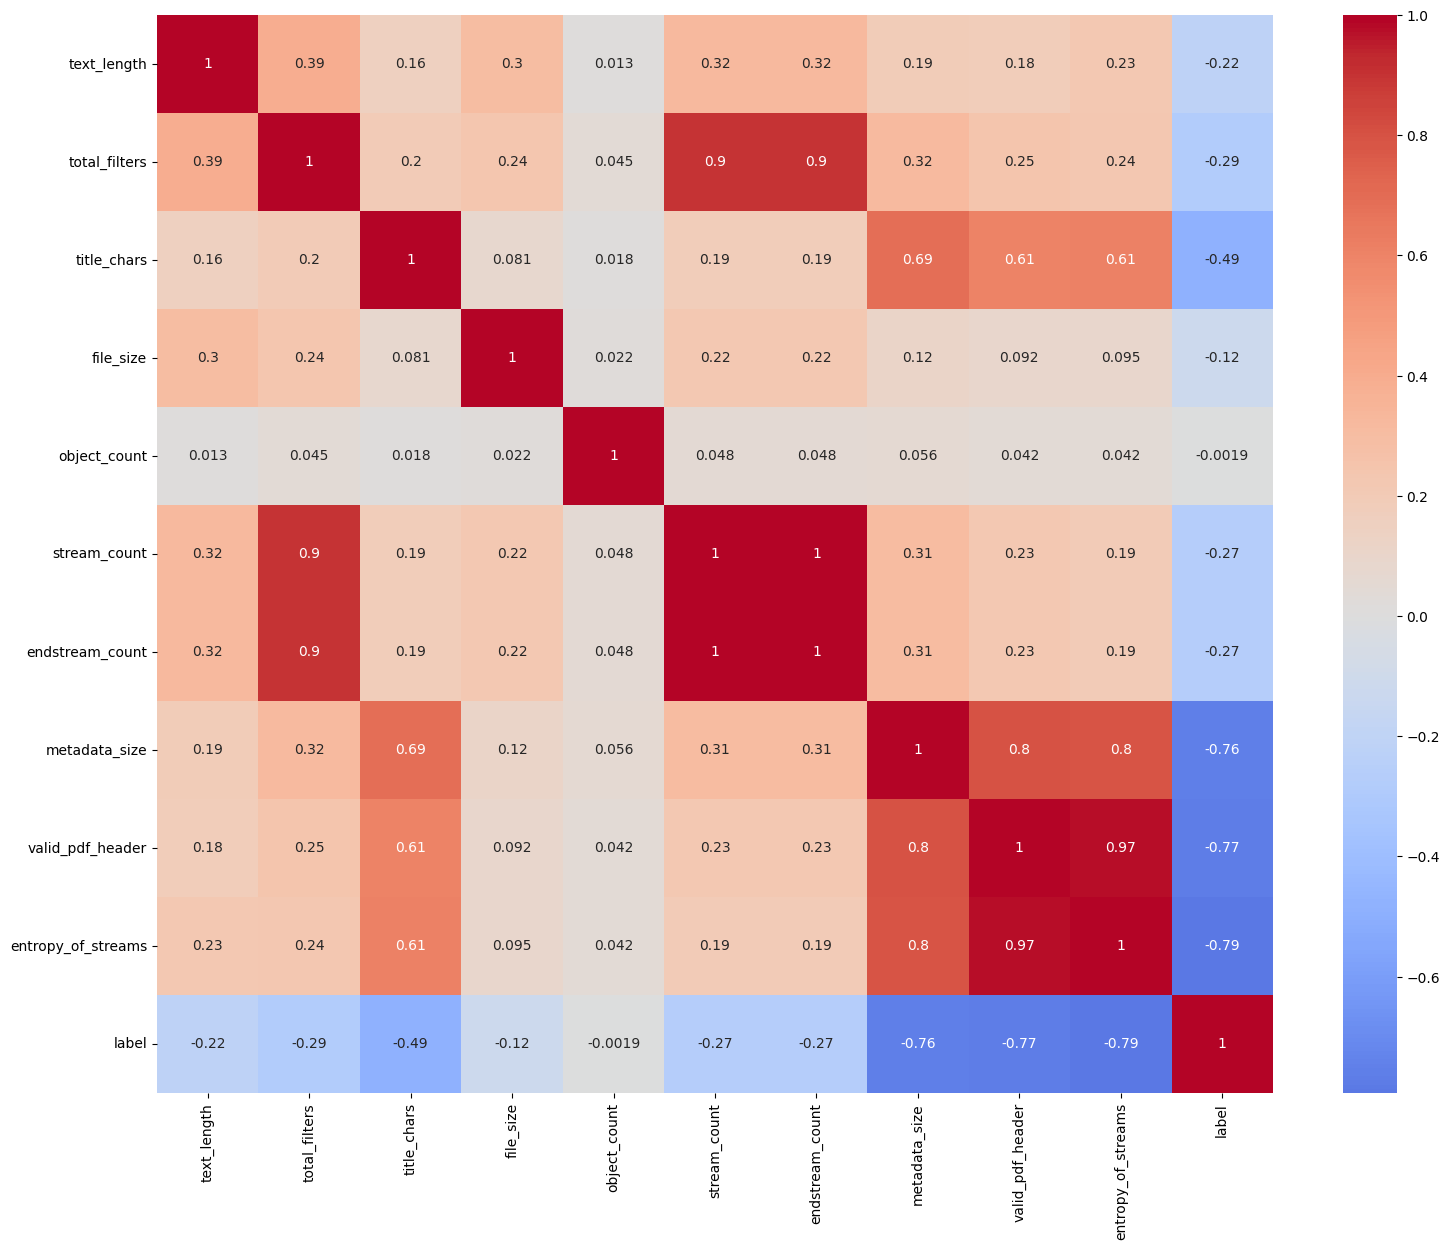

In [ ]:
# Correlation Heatmap (all features)

plt.figure(figsize=(18, 14))
corr = pdf_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

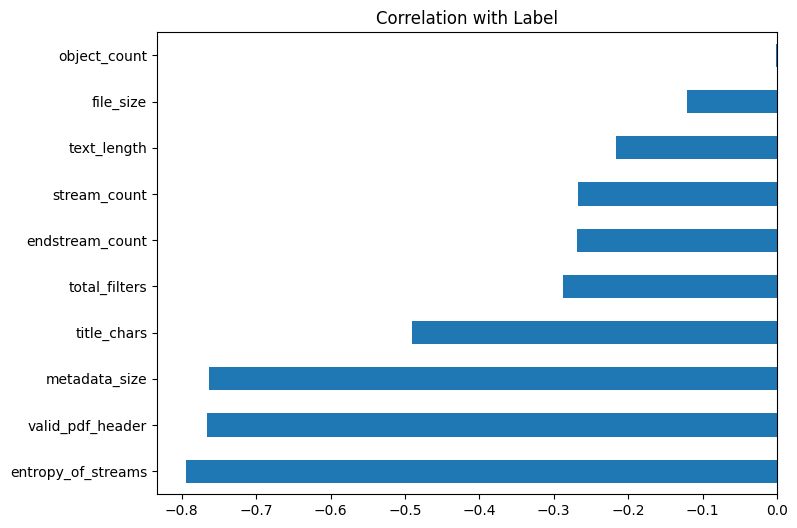

In [ ]:
# Correlation Heatmap for Label

corr = pdf_df.corr()["label"].drop('label')

corr.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Correlation with Label")
plt.show()

# Note:
# (+) correlation → associated with malicious files.
# (-) correlation → associated with benign files.

**PDF Dataset Observations!**
- The class distribution is NOT Balanced!
- There's lost samples! the dataset contains Benign: 9297, Malicious: 9999
- It does not have a file_name column
- The samples are not sorted (bengin first then malicious)

In [ ]:
X = pdf_df.drop(columns=['label'])
y = pdf_df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split (X, y, train_size=0.7, random_state=42, stratify=y)


### **1- Decision Tree**

In [ ]:
model_dt = DecisionTreeClassifier (random_state=42)
model_dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = model_dt.predict(X_test)

In [ ]:
correct = 0

for actual, predicted in zip(y_test, y_pred_dt):
    if actual == predicted:
        correct += 1

print("Correct predictions:", correct)

Correct predictions: 5754


In [ ]:
accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt, average='macro')
recall = recall_score(y_test, y_pred_dt, average='macro')
f1 = f1_score(y_test, y_pred_dt, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9940
Precision: 0.9939
Recall: 0.9940
F1-score: 0.9939


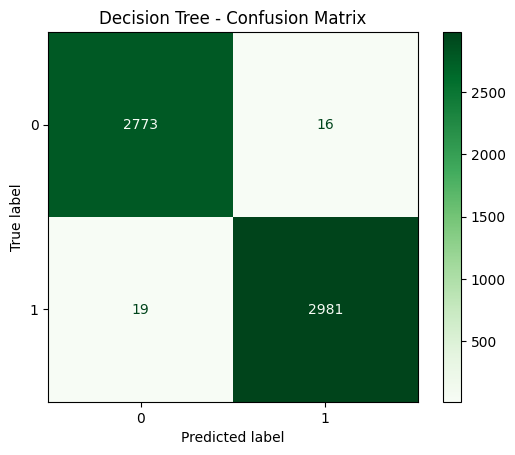

In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Greens")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

###**2- XGBoost**

In [ ]:
model_xg = XGBClassifier(random_state=42)
model_xg.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xg = model_xg.predict(X_test)

In [ ]:
correct = 0

for actual, predicted in zip(y_test, y_pred_xg):
    if actual == predicted:
        correct += 1

print("Correct predictions:", correct)

Correct predictions: 5768


In [ ]:
accuracy = accuracy_score(y_test, y_pred_xg)
precision = precision_score(y_test, y_pred_xg, average='macro')
recall = recall_score(y_test, y_pred_xg, average='macro')
f1 = f1_score(y_test, y_pred_xg, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9964
Precision: 0.9963
Recall: 0.9964
F1-score: 0.9964


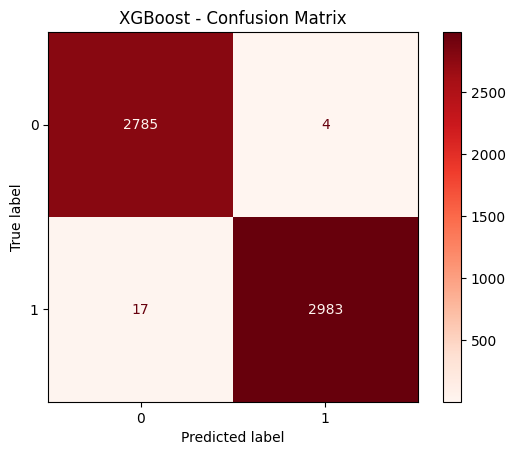

In [ ]:
cm = confusion_matrix(y_test, y_pred_xg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Reds")
plt.title("XGBoost - Confusion Matrix")
plt.show()

### **3- Random Forest**

In [ ]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit (X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = model_rf.predict(X_test)

In [ ]:
correct = 0

for actual, predicted in zip(y_test, y_pred_rf):
    if actual == predicted:
        correct += 1

print("Correct predictions:", correct)

Correct predictions: 5766


In [ ]:
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='macro')
recall = recall_score(y_test, y_pred_rf, average='macro')
f1 = f1_score(y_test, y_pred_rf, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9960
Precision: 0.9959
Recall: 0.9961
F1-score: 0.9960


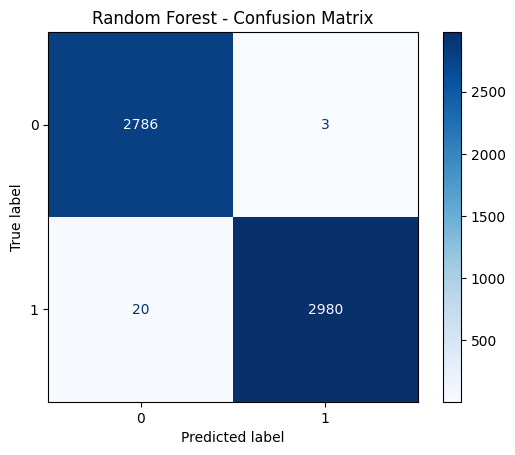

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show()